importing libraries

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from xgboost import XGBClassifier
from sklearn.metrics import (average_precision_score, f1_score, classification_report,
                              confusion_matrix, precision_recall_curve)
from scipy.sparse import hstack, csr_matrix
import joblib

pd.set_option('display.max_columns', None)

loading the data

In [3]:
df = pd.read_csv('/content/fake_job_postings.csv')
df.shape

(17880, 18)

In [4]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


EDA steps

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [6]:
# how imbalanced is the target?
df['fraudulent'].value_counts()

,count
fraudulent,
0,17014
1,866


In [7]:
df['fraudulent'].value_counts(normalize=True) * 100

,proportion
fraudulent,
0,95.1566
1,4.8434


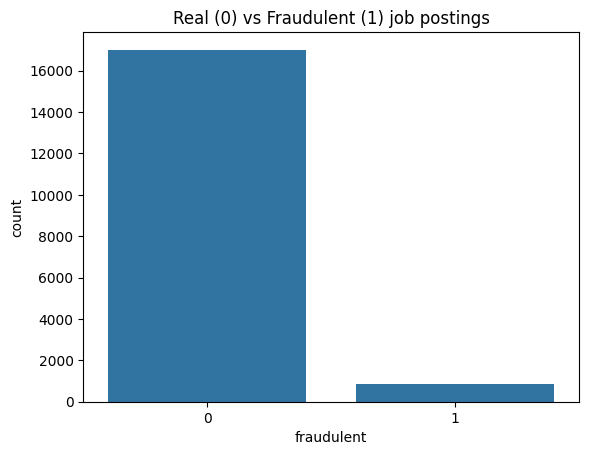

In [8]:
sns.countplot(x='fraudulent', data=df)
plt.title('Real (0) vs Fraudulent (1) job postings')
plt.show()

to check missing values in each column

In [9]:
df.isnull().sum().sort_values(ascending=False)

,0
salary_range,15012
department,11547
required_education,8105
benefits,7212
required_experience,7050
function,6455
industry,4903
employment_type,3471
company_profile,3308
requirements,2696


salary_range, department and benefits are missing for most rows. rather than dropping them, we'll turn the *fact that a field is missing* into a feature -- fake postings tend to skip sections like the company profile far more often than real ones.

In [10]:
for col in ['company_profile', 'description', 'requirements', 'benefits']:
    missing_rate = df.groupby('fraudulent')[col].apply(lambda s: s.isna().mean())
    print(col)
    print(missing_rate)
    print()

company_profile
fraudulent
0    0.159927
1    0.677829
Name: company_profile, dtype: float64

description
fraudulent
0    0.000000
1    0.001155
Name: description, dtype: float64

requirements
fraudulent
0    0.149406
1    0.177829
Name: requirements, dtype: float64

benefits
fraudulent
0    0.402492
1    0.420323
Name: benefits, dtype: float64



this confirms it: fraudulent postings are missing company_profile, requirements and benefits much more often than real ones. these 'missing_*' indicators should be useful features.

In [11]:
df.groupby('fraudulent')[['telecommuting','has_company_logo','has_questions']].mean()

,telecommuting,has_company_logo,has_questions
fraudulent,,,
0,0.041319,0.819149,0.502057
1,0.073903,0.326790,0.288684


fraudulent posts have a company logo far less often (has_company_logo), which matches intuition.

cleaning_data / feature engineering

In [12]:

text_cols = ['company_profile', 'description', 'requirements', 'benefits']


for c in text_cols:
    df[f'missing_{c}'] = df[c].isna().astype(int)

df['has_salary_range'] = df['salary_range'].notna().astype(int)

for c in text_cols + ['title']:
    df[c] = df[c].fillna('')

In [13]:
# combine all free text into one field for TF-IDF
df['full_text'] = (df['title'] + ' ' + df['company_profile'] + ' ' +
                    df['description'] + ' ' + df['requirements'] + ' ' + df['benefits'])
df['text_length'] = df['full_text'].apply(len)
df[['full_text', 'text_length']].head(2)

,full_text,text_length
0,"Marketing Intern We're Food52, and we've creat...",2662
1,Customer Service - Cloud Video Production 90 S...,6133


location is very high-cardinality (city level), so we reduce it to a country code. we'll decide which countries count as "common" (and lump the rest into 'other') using only the train set, once it's split off, so the test set doesn't leak into that decision.

In [14]:
def get_country(loc):
    if pd.isna(loc):
        return 'unknown'
    parts = str(loc).split(',')
    return parts[0].strip() if parts[0].strip() else 'unknown'

df['country'] = df['location'].apply(get_country)
df['country'].value_counts()

,count
country,
US,10656
GB,2384
GR,940
CA,457
DE,383
...,...
HR,1
SV,1
JM,1


In [15]:
categorical_columns = ['employment_type', 'required_experience', 'required_education', 'country']
for c in categorical_columns:
    df[c] = df[c].fillna('unknown')

splitting the data

In [16]:
numeric_columns = ['telecommuting', 'has_company_logo', 'has_questions', 'has_salary_range',
                    'missing_company_profile', 'missing_description',
                    'missing_requirements', 'missing_benefits', 'text_length']

y = df['fraudulent']

x_train_df, x_test_df, y_train, y_test = train_test_split(
    df, y, test_size=0.2, random_state=42, stratify=y
)

# keep only the most common countries seen in training, everything else -> 'other'
top_countries = x_train_df['country'].value_counts().nlargest(10).index.tolist()
x_train_df['country'] = x_train_df['country'].apply(lambda c: c if c in top_countries else 'other')
x_test_df['country'] = x_test_df['country'].apply(lambda c: c if c in top_countries else 'other')

x_train_df.shape, x_test_df.shape

((14304, 26), (3576, 26))

preprocessing the data

In [18]:
tfidf = TfidfVectorizer(max_features=3000, stop_words='english', min_df=3, ngram_range=(1, 2))
x_train_text = tfidf.fit_transform(x_train_df['full_text'])
x_test_text = tfidf.transform(x_test_df['full_text'])
x_train_text.shape

(14304, 3000)

In [19]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
x_train_cat = encoder.fit_transform(x_train_df[categorical_columns])
x_test_cat = encoder.transform(x_test_df[categorical_columns])
x_train_cat.shape

(14304, 39)

In [20]:
scaler = StandardScaler()
x_train_num = scaler.fit_transform(x_train_df[numeric_columns])
x_test_num = scaler.transform(x_test_df[numeric_columns])

In [21]:
x_train = hstack([x_train_text, x_train_cat, csr_matrix(x_train_num)]).tocsr()
x_test = hstack([x_test_text, x_test_cat, csr_matrix(x_test_num)]).tocsr()
x_train.shape

(14304, 3048)

try some models and choose the best one

In [22]:
from sklearn.model_selection import cross_val_score

cv_results = {}

def compare(name, model, X):
    scores = cross_val_score(model, X, y_train, cv=5, scoring='average_precision', n_jobs=-1)
    cv_results[name] = scores.mean()
    print(f"{name:22s}  PR-AUC (5-fold CV) = {scores.mean():.4f}")

In [23]:
log_reg = LogisticRegression(max_iter=3000, class_weight='balanced', C=10)
compare('Logistic Regression', log_reg, x_train)

Logistic Regression     PR-AUC (5-fold CV) = 0.8498


In [25]:
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)
compare('Random Forest', rf, x_train)

Random Forest           PR-AUC (5-fold CV) = 0.8672


In [28]:
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
compare('Gradient Boosting', gb, x_train)

Gradient Boosting       PR-AUC (5-fold CV) = 0.7859


In [29]:
xgb = XGBClassifier(
    n_estimators=300, max_depth=6,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='logloss', random_state=42
)
compare('XGBoost', xgb, x_train)

XGBoost                 PR-AUC (5-fold CV) = 0.8821


second model we will work on is Naive Bayes -- as a simple text-only baseline (raw counts, no engineered/categorical features)

In [31]:
count_vec = CountVectorizer(max_features=3000, stop_words='english', min_df=3)
xtr_counts = count_vec.fit_transform(x_train_df['full_text'])

nb = MultinomialNB()
compare('Naive Bayes (text only)', nb, xtr_counts)

Naive Bayes (text only)  PR-AUC (5-fold CV) = 0.4743


In [32]:
pd.Series(cv_results, name='pr_auc').sort_values(ascending=False)

,pr_auc
XGBoost,0.882117
Random Forest,0.867173
Logistic Regression,0.849816
Gradient Boosting,0.785892
Naive Bayes (text only),0.474282


XGBoost comes out on top on cross-validated PR-AUC, with Random Forest close behind. Logistic Regression trails both a bit, but it's not far off, and its score is *just a weighted sum of features passed through a sigmoid* -- no tree ensemble to carry around. Naive Bayes on text alone is clearly too weak on its own; the engineered/categorical features are pulling real weight for every other model.

based on the cross-validation comparison, XGBoost has the strongest average PR-AUC. I'll refit it on the full training set and only touch the test set now, once, for the final numbers.

In [33]:
xgb.fit(x_train, y_train)

proba = xgb.predict_proba(x_test)[:, 1]
preds = (proba >= 0.5).astype(int)
print(classification_report(y_test, preds, target_names=['real', 'fraudulent'], zero_division=0))

              precision    recall  f1-score   support

        real       0.99      1.00      0.99      3403
  fraudulent       0.93      0.83      0.88       173

    accuracy                           0.99      3576
   macro avg       0.96      0.91      0.94      3576
weighted avg       0.99      0.99      0.99      3576



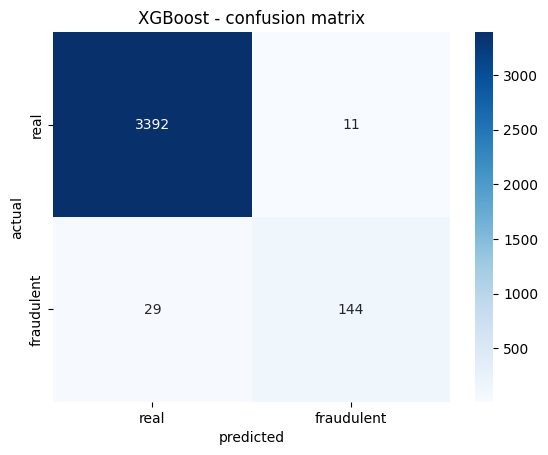

In [34]:
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['real', 'fraudulent'], yticklabels=['real', 'fraudulent'])
plt.ylabel('actual')
plt.xlabel('predicted')
plt.title('XGBoost - confusion matrix')
plt.show()

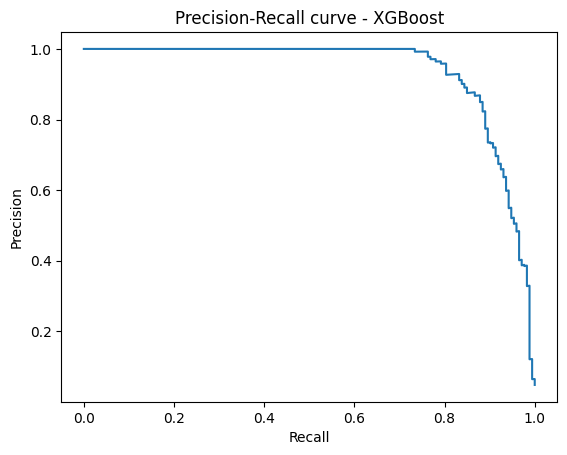

In [35]:
precision, recall, thresholds = precision_recall_curve(y_test, proba)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve - XGBoost')
plt.show()

top features by importance in the XGBoost model. importance here just means how much the feature was used to split the trees -- it's not signed, so it doesn't tell us whether a feature pushes a posting toward 'fraudulent' or away from it (for that you'd need something like SHAP values).

In [36]:
feature_names = np.array(
    list(tfidf.get_feature_names_out()) +
    list(encoder.get_feature_names_out(categorical_columns)) +
    numeric_columns
)
importances = xgb.feature_importances_
top_idx = np.argsort(importances)[-20:][::-1]
pd.DataFrame({'feature': feature_names[top_idx], 'importance': importances[top_idx]})

,feature,importance
0,encouraged,0.046444
1,missing_company_profile,0.031736
2,guests,0.028141
3,hiring process,0.027154
4,average,0.025191
5,real estate,0.024345
6,required_education_High School or equivalent,0.020292
7,right,0.018546
8,excellence,0.017964
9,schedule,0.015453


saving the model

In [37]:
joblib.dump(xgb, 'xgboost_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(encoder, 'onehot_encoder.pkl')
joblib.dump(scaler, 'standard_scaler.pkl')
print('Models and preprocessing objects saved.')

Models and preprocessing objects saved.
